In [26]:
# Step 1: Import required libraries and modules
import sys, os
sys.path.append(os.path.abspath("..")) 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

from models.mobilenetv3 import MobileNetV3Extractor
from models.lstm_attention import BiLSTMWithAttention
from preprocessing.dataset import SignLanguageDataset

In [14]:
import torch
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
Using device: cuda


In [15]:
# Step 2: Define data paths and label mapping

train_root = "../data/frames/train"
val_root = "../data/frames/validation"

# Obtain the category list and establish the tag mapping.
class_names = sorted([
    d for d in os.listdir(train_root)
    if os.path.isdir(os.path.join(train_root, d)) and not d.startswith(".")
])
label_map = {name: idx for idx, name in enumerate(class_names)}

print("Discovered classes:", label_map)
print("Total number of classes:", len(label_map))

Discovered classes: {'accident': 0, 'africa': 1, 'all': 2, 'apple': 3, 'basketball': 4, 'bed': 5, 'before': 6, 'bird': 7, 'birthday': 8, 'black': 9, 'blue': 10, 'book': 11, 'bowling': 12, 'brown': 13, 'but': 14, 'can': 15, 'candy': 16, 'chair': 17, 'change': 18, 'cheat': 19, 'city': 20, 'clothes': 21, 'color': 22, 'computer': 23, 'cook': 24, 'cool': 25, 'corn': 26, 'cousin': 27, 'cow': 28, 'dance': 29, 'dark': 30, 'deaf': 31, 'decide': 32, 'doctor': 33, 'dog': 34, 'drink': 35, 'eat': 36, 'enjoy': 37, 'family': 38, 'fine': 39, 'finish': 40, 'fish': 41, 'forget': 42, 'full': 43, 'give': 44, 'go': 45, 'graduate': 46, 'hat': 47, 'hearing': 48, 'help': 49, 'hot': 50, 'how': 51, 'jacket': 52, 'kiss': 53, 'language': 54, 'last': 55, 'later': 56, 'letter': 57, 'like': 58, 'man': 59, 'many': 60, 'medicine': 61, 'meet': 62, 'mother': 63, 'need': 64, 'no': 65, 'now': 66, 'orange': 67, 'paint': 68, 'paper': 69, 'pink': 70, 'pizza': 71, 'play': 72, 'pull': 73, 'purple': 74, 'right': 75, 'same': 76,

In [16]:
# Step 3: Define two different data augmentation strategies

# Basic transforms (for experiment 1)
train_transform_basic = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Enhanced transforms (for experiment 2)
train_transform_aug = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.RandomRotate90(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Validation transforms (same for both experiments)
val_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

print("Data augmentation strategies defined:")
print("Basic transforms:", len(train_transform_basic))
print("Enhanced transforms:", len(train_transform_aug))

Data augmentation strategies defined:
Basic transforms: 3
Enhanced transforms: 7


/tmp/ipykernel_33454/929399228.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.3),


In [17]:
# Step 4: Define the full model structure

class FullSLRModel(nn.Module):
    def __init__(self, num_classes, hidden_dim=128, num_layers=2):
        super().__init__()
        self.feature_extractor = MobileNetV3Extractor()
        self.temporal_model = BiLSTMWithAttention(
            input_dim=960, 
            hidden_dim=hidden_dim, 
            num_classes=num_classes,
            num_layers=num_layers
        )

    def forward(self, x):  # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        features = self.feature_extractor(x)  # [B*T, 960]
        features = features.view(B, T, -1)    # [B, T, 960]
        logits, _ = self.temporal_model(features)
        return logits

In [18]:
# Step 5: Define training and validation functions

from torch.cuda.amp import autocast, GradScaler

def train_epoch(model, train_loader, criterion, optimizer, scaler, device):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    loop = tqdm(train_loader, desc='Training')
    for batch_idx, (videos, labels) in enumerate(loop):
        videos = videos.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(videos)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        train_loss += loss.item()
        
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    
    train_loss = train_loss / len(train_loader)
    train_acc = 100. * correct / total
    return train_loss, train_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in tqdm(val_loader, desc='Validating'):
            videos = videos.to(device)
            labels = labels.to(device)
            
            with autocast():
                outputs = model(videos)
                loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc

In [19]:
# Step 6: Experiment 1 - MobileNetV3 + LSTM + Attention (Basic)

print("EXPERIMENT 1: MobileNetV3 + LSTM + Attention (Basic)")

# Create datasets and dataloaders for experiment 1
train_dataset_basic = SignLanguageDataset(
    root_dir=train_root,
    label_map=label_map,
    transform=train_transform_basic
)

val_dataset = SignLanguageDataset(
    root_dir=val_root,
    label_map=label_map,
    transform=val_transform
)

train_loader_basic = DataLoader(train_dataset_basic, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

# Initialize model, criterion, optimizer for experiment 1
model_basic = FullSLRModel(num_classes=len(label_map)).to(device)
criterion_basic = nn.CrossEntropyLoss(label_smoothing=0)  # No label smoothing
optimizer_basic = optim.Adam(model_basic.parameters(), lr=1e-4, weight_decay=1e-4)
scaler_basic = GradScaler()

# Check if there is a saved model to enable continued training.
start_epoch = 0
if os.path.exists('experiment1_best_model.pth'):
    model_basic.load_state_dict(torch.load('experiment1_best_model.pth'))
    print("Loaded existing experiment1 model, continuing training...")
    start_epoch = 10 
else:
    print("Starting experiment1 training from scratch...")

# Training loop for experiment 1
num_epochs = 20
train_loss_list_basic, val_loss_list_basic = [], []
train_acc_list_basic, val_acc_list_basic = [], []
best_val_acc_basic = 0.0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Training
    train_loss, train_acc = train_epoch(
        model_basic, train_loader_basic, criterion_basic, 
        optimizer_basic, scaler_basic, device
    )
    
    # Validation
    val_loss, val_acc = validate(model_basic, val_loader, criterion_basic, device)
    
    # Record metrics
    train_loss_list_basic.append(train_loss)
    train_acc_list_basic.append(train_acc)
    val_loss_list_basic.append(val_loss)
    val_acc_list_basic.append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc_basic:
        best_val_acc_basic = val_acc
        torch.save(model_basic.state_dict(), 'experiment1_best_model.pth')
        print(f'New best model saved with val_acc: {val_acc:.2f}%')
    
    print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

print(f"\nExperiment 1 - Best Validation Accuracy: {best_val_acc_basic:.2f}%")

EXPERIMENT 1: MobileNetV3 + LSTM + Attention (Basic)

[DEBUG] First 5 samples loaded:
Sample 0: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00618/frame_000.jpg
Sample 1: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00623/frame_000.jpg
Sample 2: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00624/frame_000.jpg
Sample 3: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00628/frame_000.jpg
Sample 4: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00629/frame_000.jpg

[DEBUG] First 5 samples loaded:
Sample 0: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/validation/accident/00626/frame_000.jpg
Sample 1: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/validation/accident/00627/frame_000.jpg
Sample 2: class=africa, label=1
    Fr

/tmp/ipykernel_33454/204990522.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_basic = GradScaler()
/tmp/ipykernel_33454/204990522.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control 

Loaded existing experiment1 model, continuing training...

Epoch 1/20


Training:   0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipykernel_33454/828101742.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validating:   0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_33454/828101742.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validating: 100%|██████████| 31/31 [00:07<00:00,  3.90it/s]


New best model saved with val_acc: 19.83%
Epoch 1: Train Loss: 2.4324 | Train Acc: 47.65% | Val Loss: 3.5718 | Val Acc: 19.83%

Epoch 2/20


...

Epoch 18: Train Loss: 0.3131 | Train Acc: 98.20% | Val Loss: 3.3633 | Val Acc: 27.27%

Epoch 19/20


Validating: 100%|██████████| 31/31 [00:07<00:00,  4.26it/s]


New best model saved with val_acc: 32.23%
Epoch 19: Train Loss: 0.2808 | Train Acc: 98.40% | Val Loss: 3.2947 | Val Acc: 32.23%

Epoch 20/20


Validating: 100%|██████████| 31/31 [00:07<00:00,  4.27it/s]

Epoch 20: Train Loss: 0.2383 | Train Acc: 98.50% | Val Loss: 3.3924 | Val Acc: 29.75%

Experiment 1 - Best Validation Accuracy: 32.23%


In [20]:
# Step 7: Experiment 2 - MobileNetV3 + LSTM + Attention + Augmentation + Label Smoothing

print("EXPERIMENT 2: MobileNetV3 + LSTM + Attention + Augmentation + Label Smoothing")

# Create datasets and dataloaders for experiment 2
train_dataset_aug = SignLanguageDataset(
    root_dir=train_root,
    label_map=label_map,
    transform=train_transform_aug
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=8, shuffle=True, num_workers=2)

# Initialize model, criterion, optimizer for experiment 2
model_aug = FullSLRModel(num_classes=len(label_map)).to(device)
criterion_aug = nn.CrossEntropyLoss(label_smoothing=0.1)  # With label smoothing
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-4, weight_decay=1e-4)
scaler_aug = GradScaler()

# Check if there is a saved model to enable continued training.
start_epoch = 0
if os.path.exists('experiment2_best_model.pth'):
    model_aug.load_state_dict(torch.load('experiment2_best_model.pth'))
    print("Loaded existing experiment2 model, continuing training...")
    start_epoch = 10 
else:
    print("Starting experiment2 training from scratch...")

# Training loop for experiment 2
train_loss_list_aug, val_loss_list_aug = [], []
train_acc_list_aug, val_acc_list_aug = [], []
best_val_acc_aug = 0.0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Training
    train_loss, train_acc = train_epoch(
        model_aug, train_loader_aug, criterion_aug, 
        optimizer_aug, scaler_aug, device
    )
    
    # Validation
    val_loss, val_acc = validate(model_aug, val_loader, criterion_aug, device)
    
    # Record metrics
    train_loss_list_aug.append(train_loss)
    train_acc_list_aug.append(train_acc)
    val_loss_list_aug.append(val_loss)
    val_acc_list_aug.append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc_aug:
        best_val_acc_aug = val_acc
        torch.save(model_aug.state_dict(), 'experiment2_best_model.pth')
        print(f'New best model saved with val_acc: {val_acc:.2f}%')
    
    print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

print(f"\nExperiment 2 - Best Validation Accuracy: {best_val_acc_aug:.2f}%")

EXPERIMENT 2: MobileNetV3 + LSTM + Attention + Augmentation + Label Smoothing

[DEBUG] First 5 samples loaded:
Sample 0: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00618/frame_000.jpg
Sample 1: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00623/frame_000.jpg
Sample 2: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00624/frame_000.jpg
Sample 3: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00628/frame_000.jpg
Sample 4: class=accident, label=0
    Frame count: 16 | First frame: ../data/frames/train/accident/00629/frame_000.jpg


/tmp/ipykernel_33454/3638392573.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_aug = GradScaler()
/tmp/ipykernel_33454/3638392573.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control 

Loaded existing experiment2 model, continuing training...

Epoch 1/20


Training:   0%|          | 0/125 [00:00<?, ?it/s]/tmp/ipykernel_33454/828101742.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validating:   0%|          | 0/31 [00:00<?, ?it/s]/tmp/ipykernel_33454/828101742.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validating: 100%|██████████| 31/31 [00:07<00:00,  4.20it/s]


New best model saved with val_acc: 15.70%
Epoch 1: Train Loss: 2.9375 | Train Acc: 44.24% | Val Loss: 3.9078 | Val Acc: 15.70%

Epoch 2/20


...

New best model saved with val_acc: 26.45%
Epoch 18: Train Loss: 1.3346 | Train Acc: 95.80% | Val Loss: 3.7039 | Val Acc: 26.45%

Epoch 19/20


Validating: 100%|██████████| 31/31 [00:07<00:00,  4.22it/s]


Epoch 19: Train Loss: 1.2852 | Train Acc: 95.40% | Val Loss: 3.8409 | Val Acc: 21.90%

Epoch 20/20


Validating: 100%|██████████| 31/31 [00:07<00:00,  3.95it/s]

Epoch 20: Train Loss: 1.2442 | Train Acc: 96.20% | Val Loss: 3.7889 | Val Acc: 25.21%

Experiment 2 - Best Validation Accuracy: 26.45%


COMPARISON RESULTS
Experiment 1 (Basic): Best Val Acc = 32.23%
Experiment 2 (Augmented): Best Val Acc = 26.45%
Improvement: -5.79%


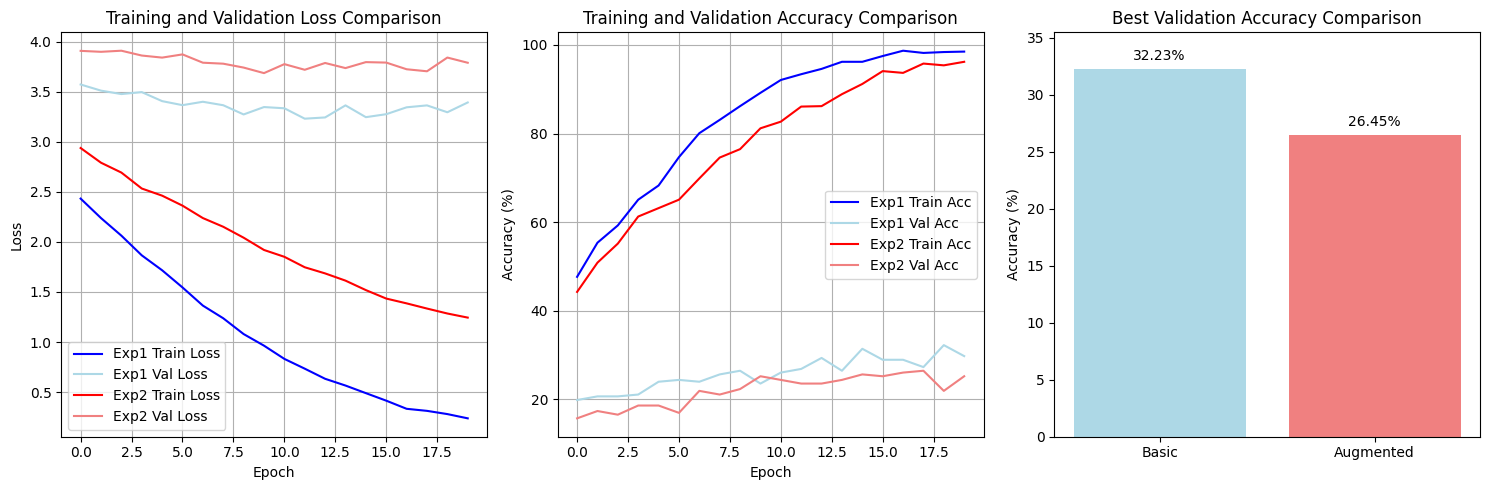


Detailed Comparison:
Metric               Experiment 1    Experiment 2    Difference     
-----------------------------------------------------------------
Best Val Acc         32.23           26.45           -5.79          
Final Train Acc      98.50           96.20           -2.30          
Final Val Acc        29.75           25.21           -4.55          


In [23]:
# Step 8: Compare and visualize results

print("COMPARISON RESULTS")

print(f"Experiment 1 (Basic): Best Val Acc = {best_val_acc_basic:.2f}%")
print(f"Experiment 2 (Augmented): Best Val Acc = {best_val_acc_aug:.2f}%")
print(f"Improvement: {best_val_acc_aug - best_val_acc_basic:.2f}%")

# Create comparison plots
plt.figure(figsize=(15, 5))

# Loss comparison
plt.subplot(1, 3, 1)
plt.plot(train_loss_list_basic, label='Exp1 Train Loss', color='blue')
plt.plot(val_loss_list_basic, label='Exp1 Val Loss', color='lightblue')
plt.plot(train_loss_list_aug, label='Exp2 Train Loss', color='red')
plt.plot(val_loss_list_aug, label='Exp2 Val Loss', color='lightcoral')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 3, 2)
plt.plot(train_acc_list_basic, label='Exp1 Train Acc', color='blue')
plt.plot(val_acc_list_basic, label='Exp1 Val Acc', color='lightblue')
plt.plot(train_acc_list_aug, label='Exp2 Train Acc', color='red')
plt.plot(val_acc_list_aug, label='Exp2 Val Acc', color='lightcoral')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Final comparison bar chart
plt.subplot(1, 3, 3)
experiments = ['Basic', 'Augmented']
best_accs = [best_val_acc_basic, best_val_acc_aug]
colors = ['lightblue', 'lightcoral']
bars = plt.bar(experiments, best_accs, color=colors)
plt.title('Best Validation Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, max(best_accs) * 1.1)

# Add value labels on bars
for bar, acc in zip(bars, best_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\nDetailed Comparison:")
print(f"{'Metric':<20} {'Experiment 1':<15} {'Experiment 2':<15} {'Difference':<15}")
print("-" * 65)
print(f"{'Best Val Acc':<20} {best_val_acc_basic:<15.2f} {best_val_acc_aug:<15.2f} {best_val_acc_aug - best_val_acc_basic:<15.2f}")
print(f"{'Final Train Acc':<20} {train_acc_list_basic[-1]:<15.2f} {train_acc_list_aug[-1]:<15.2f} {train_acc_list_aug[-1] - train_acc_list_basic[-1]:<15.2f}")
print(f"{'Final Val Acc':<20} {val_acc_list_basic[-1]:<15.2f} {val_acc_list_aug[-1]:<15.2f} {val_acc_list_aug[-1] - val_acc_list_basic[-1]:<15.2f}")

In [24]:
# Step 9: Save experiment results

import json
from datetime import datetime

# Create results dictionary
results = {
    'experiment_info': {
        'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'num_classes': len(label_map),
        'num_epochs': num_epochs,
        'device': str(device)
    },
    'experiment_1': {
        'name': 'MobileNetV3 + LSTM + Attention (Basic)',
        'data_augmentation': 'Basic (Resize + Normalize)',
        'label_smoothing': 0,
        'best_val_acc': best_val_acc_basic,
        'train_loss_history': train_loss_list_basic,
        'val_loss_history': val_loss_list_basic,
        'train_acc_history': train_acc_list_basic,
        'val_acc_history': val_acc_list_basic
    },
    'experiment_2': {
        'name': 'MobileNetV3 + LSTM + Attention + Augmentation + Label Smoothing',
        'data_augmentation': 'Enhanced (Flip + Brightness + Rotation + Dropout)',
        'label_smoothing': 0.1,
        'best_val_acc': best_val_acc_aug,
        'train_loss_history': train_loss_list_aug,
        'val_loss_history': val_loss_list_aug,
        'train_acc_history': train_acc_list_aug,
        'val_acc_history': val_acc_list_aug
    }
}

# Save results to JSON file
with open('contrast_experiment_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nExperiment results saved to 'contrast_experiment_results.json'")
print("Best models saved as:")
print("- experiment1_best_model.pth")
print("- experiment2_best_model.pth")


Experiment results saved to 'contrast_experiment_results.json'
Best models saved as:
- experiment1_best_model.pth
- experiment2_best_model.pth
